In [1]:
!pip install scikit-learn

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier # Added AdaBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier

In [10]:
df = pd.read_csv('Train_dataset.csv')

In [11]:
df.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [12]:
df.isna().sum()

,0
SEQN,12
RIAGENDR,18
PAQ605,13
BMXBMI,18
LBXGLU,13
DIQ010,18
LBXGLT,11
LBXIN,9
age_group,14


In [13]:
df.shape

(1966, 9)

In [14]:
for col in df.columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_543/893124906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [15]:
df.isna().sum()

,0
SEQN,0
RIAGENDR,0
PAQ605,0
BMXBMI,0
LBXGLU,0
DIQ010,0
LBXGLT,0
LBXIN,0
age_group,0


In [16]:
encoder = LabelEncoder()
df['age_group'] = encoder.fit_transform(df['age_group'])

<Axes: >

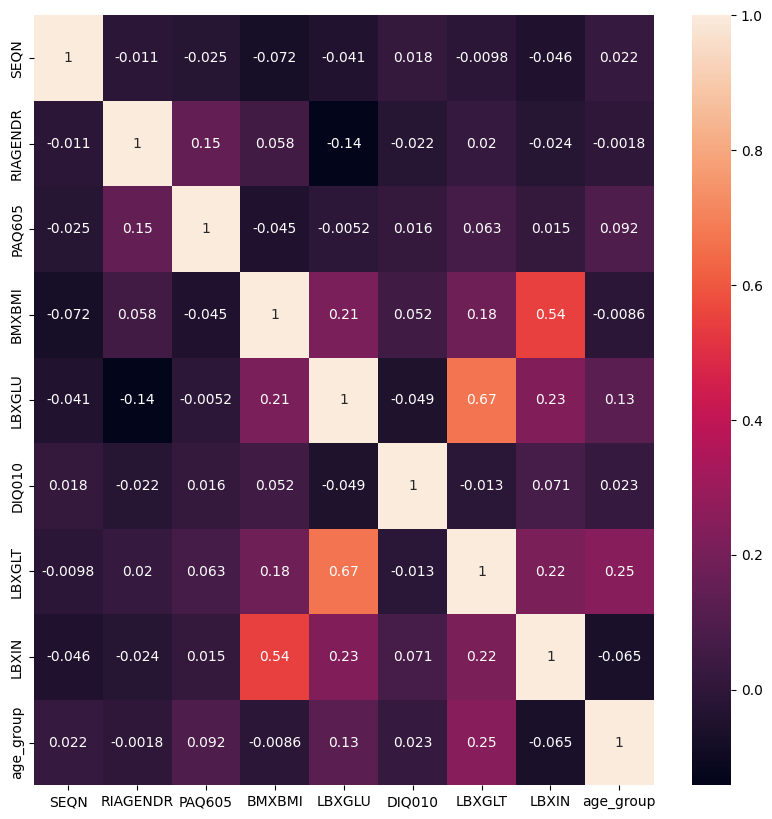

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

In [18]:
x = df.drop(['age_group',"SEQN",'BMXBMI',"RIAGENDR"],axis=1)
y = df['age_group']

In [19]:
y

,age_group
0,0
1,0
2,0
3,0
4,0
...,...
1961,0
1962,0
1963,0
1964,0


In [20]:
y.value_counts()

,count
age_group,
0,1652
1,314


In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [27]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Features scaled successfully.")

Features scaled successfully.


In [43]:
models = {
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'DecisionTreeClassifier': {
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'max_depth': [None, 10, 20, 30],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'SVC': {
        'model': SVC(random_state=42),
        'param_grid': {
            'C': [0.1, 1],
            'kernel': ['linear', 'rbf']
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, solver='liblinear'),
        'param_grid': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2']
        }
    },
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    },
    'GaussianNB': {
        'model': GaussianNB(),
        'param_grid': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    'XGBClassifier': {
        'model': xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        }
    },
    'AdaBoostClassifier': {
        'model': AdaBoostClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 1.0]
        }
    }
}

In [39]:
def find_best_model(models, x_train, y_train):
  for model_name, config in models.items():
    print(f"\n--- {model_name} Tuning ---")
    grid_search = GridSearchCV(config['model'], config['param_grid'], cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(x_train, y_train)

    print(f"Best Parameters ({model_name}): {grid_search.best_params_}")
    print(f"Best Score ({model_name}): {grid_search.best_score_:.4f}")

In [44]:
find_best_model(models, x_train_scaled, y_train)


--- RandomForestClassifier Tuning ---
Best Parameters (RandomForestClassifier): {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Best Score (RandomForestClassifier): 0.8089

--- DecisionTreeClassifier Tuning ---
Best Parameters (DecisionTreeClassifier): {'max_depth': 10, 'min_samples_leaf': 4}
Best Score (DecisionTreeClassifier): 0.7879

--- SVC Tuning ---
Best Parameters (SVC): {'C': 1, 'kernel': 'rbf'}
Best Score (SVC): 0.7793

--- LogisticRegression Tuning ---
Best Parameters (LogisticRegression): {'C': 10, 'penalty': 'l1'}
Best Score (LogisticRegression): 0.7820

--- KNeighborsClassifier Tuning ---
Best Parameters (KNeighborsClassifier): {'n_neighbors': 7, 'weights': 'distance'}
Best Score (KNeighborsClassifier): 0.8156

--- GaussianNB Tuning ---
Best Parameters (GaussianNB): {'var_smoothing': 1e-09}
Best Score (GaussianNB): 0.7937

--- XGBClassifier Tuning ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:27:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters (XGBClassifier): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best Score (XGBClassifier): 0.8021

--- AdaBoostClassifier Tuning ---
Best Parameters (AdaBoostClassifier): {'learning_rate': 1.0, 'n_estimators': 200}
Best Score (AdaBoostClassifier): 0.7999


In [45]:
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
model.fit(x_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:28:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
classification_report = classification_report(y_test, model.predict(x_test))
print("Classification Report:\n", classification_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92       338
           1       0.00      0.00      0.00        56

    accuracy                           0.86       394
   macro avg       0.43      0.50      0.46       394
weighted avg       0.74      0.86      0.79       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
test_df = pd.read_csv('Test_dataset.csv')
df.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,0
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,0
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,0
3,73577.0,1.0,2.0,28.9,104.0,2.0,84.0,16.15,0
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,0


In [50]:
test_df = test_df.drop(['SEQN','BMXBMI',"RIAGENDR"],axis=1)

In [57]:
op = pd.DataFrame(model.predict(test_df))

In [58]:
op.rename(columns={0:'age_group'},inplace=True)

In [59]:
op

,age_group
0,0
1,0
2,0
3,0
4,0
...,...
307,0
308,0
309,0
310,0


In [66]:
op.reset_index(drop=True,inplace=True)

In [69]:
op

,age_group
0,0
1,0
2,0
3,0
4,0
...,...
307,0
308,0
309,0
310,0


In [70]:
op.to_csv("submission.csv", index=False)